# Case Study: Do Aha! Moments Mark Creative Ideas?
### Bayesian linear mediation with participant random effects

*Based on:* the Moroshkina-lab project on Aha! experiences in divergent thinking
(final `v1` analysis pipeline), re-implemented in teaching form. **N = 102 participants,
1,534 ideas.**

**The phenomenon.** In insight problem solving, solutions that arrive with an "Aha!" feel
are remembered better and seem special. A bold hypothesis: the Aha experience is a *marker*
of creative quality — ideas accompanied by Aha! are genuinely more creative. A sober
confound: as an idea-generation session progresses, ideas get both more creative *and* more
likely to trigger Aha! (serial-order effects). Is there anything left of the Aha–creativity
link once time is accounted for?

**The design.** Participants generate unusual uses for a newspaper (divergent thinking).
After **each idea** they report whether they experienced an Aha! moment (binary) and its
intensity. Every idea is later scored for **creativity** (OCSAI) and **elaboration**
(detail richness). This gives an idea-level three-variable system:

$$\mathrm{Aha!} \rightarrow \mathrm{Elaboration} \rightarrow \mathrm{Creativity}$$

**What you will learn:**
1. Bayesian **mediation analysis**: direct, indirect (through a mediator), and total effects,
   all with full posterior uncertainty.
2. The causal discipline of **mediator vs covariate**: a variable that *precedes* the
   treatment cannot sit on the causal path — and how the analysis was restructured when this
   was realized (a real, documented modeling correction).
3. Within-participant standardization to separate "between persons" from "within person over
   time".
4. A pre-registered-style **decision rule**: an effect counts as present when
   $P(\text{direction}) \ge 0.95$.

**Running on Colab?** Execute the next cell once to download the data files.

In [ ]:
import os
if not os.path.exists("data/creativity"):
!wget -q -P data/creativity https://raw.githubusercontent.com/iknyazeva/bayes-cogsci-book/main/case_studies/data/creativity/data_aha_creativity.xlsx

In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

import numpy as np
import pandas as pd
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
import seaborn as sns

print("pymc:", pm.__version__, "| arviz:", az.__version__, "| pandas:", pd.__version__)
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 4)

DATA_DIR = "data/creativity"
FIG_DIR = "figures"
import os
os.makedirs(FIG_DIR, exist_ok=True)

def save_fig(fig, name):
    fig.savefig(f"{FIG_DIR}/{name}", dpi=150, bbox_inches="tight")
    print("saved:", f"{FIG_DIR}/{name}")

BETA_SD = 1.0        # Normal(0, 1) slopes on standardized predictors
SIGMA_RATE = 1.0     # Exponential(1) scales
DECISION_P = 0.95    # effect-present rule

pymc: 5.28.0 | arviz: 0.23.4 | pandas: 3.0.2


## 1. From data to analysis frame

The raw sheet holds one row per idea. Following the project's final (`v1`) preprocessing:

* keep only valid newspaper-task ideas (participant- and expert-approved);
* cap elaboration at 30 (extremely long answers stop adding information);
* **standardize within participant**: creativity, elaboration, idea sequence — so effects
  are "within this person, across their ideas", not "between slow and fast people";
* Aha **intensity**: z-scored within participant *using Aha trials only*, then set to 0 on
  non-Aha trials — the intensity dial is only active when Aha occurred.

```{admonition} Why within-participant standardization?
:class: tip
Each participant uses the rating scale differently and produces a different number of ideas.
Z-scoring *within* person removes scale usage and output volume differences, so a slope of
0.2 means "0.2 of *this person's own* creativity spread". It also makes the participant
random intercepts cleaner: they capture residual person-level baseline, not scale usage.
```

In [2]:
df = pd.read_excel(f"{DATA_DIR}/data_aha_creativity.xlsx",
                   usecols=["participant", "idea_sequence", "aha_occurrence", "aha_rating",
                            "elaboration_OCSAI", "creativity_OCSAI", "idea_out", "part_out",
                            "task_g"])
df = df[(df.task_g == "newspaper") & (df.part_out == 0) & (df.idea_out == 0)].reset_index(drop=True)
df["elaboration_OCSAI"] = df["elaboration_OCSAI"].clip(upper=30)

# Aha intensity: z within participant on Aha trials only; 0 on non-Aha trials
def z_aha(grp):
    mask = grp["aha_occurrence"].astype(int) == 1
    out = pd.Series(0.0, index=grp.index)
    if mask.sum() > 1 and grp.loc[mask, "aha_rating"].std() > 0:
        vals = grp.loc[mask, "aha_rating"]
        out.loc[mask] = (vals - vals.mean()) / vals.std()
    return out

df["aha_rating_active"] = df.groupby("participant", group_keys=False).apply(z_aha, include_groups=False)

for col in ["idea_sequence", "creativity_OCSAI", "elaboration_OCSAI"]:
    df[col + "_z"] = df.groupby("participant")[col].transform(
        lambda x: (x - x.mean()) / x.std() if x.std() > 0 else 0)

crea = df["creativity_OCSAI_z"].values
elab = df["elaboration_OCSAI_z"].values
trial = df["idea_sequence_z"].values
aha_bin = df["aha_occurrence"].astype(int).values
aha_rating = df["aha_rating_active"].values
pidx, pids = pd.factorize(df["participant"])
print(f"ideas: {len(df)} | participants: {len(pids)} | Aha rate: {aha_bin.mean():.3f}")

ideas: 1534 | participants: 102 | Aha rate: 0.539


saved: figures/eda.png


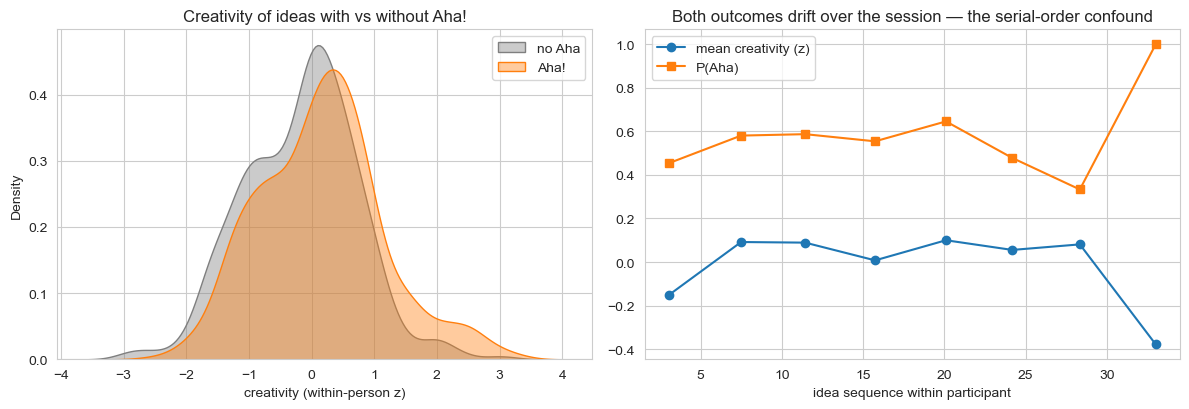

In [3]:
# ---- EDA ----
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

ax = axes[0]
for v, color, name in [(0, "tab:grey", "no Aha"), (1, "tab:orange", "Aha!")]:
    sns.kdeplot(crea[aha_bin == v], ax=ax, color=color, fill=True, alpha=0.4, label=name)
ax.set_xlabel("creativity (within-person z)")
ax.set_title("Creativity of ideas with vs without Aha!")
ax.legend()

ax = axes[1]
bins = pd.cut(df.idea_sequence, bins=8)
ser = df.groupby(bins, observed=True).agg(x=("idea_sequence", "mean"),
                                          crea=("creativity_OCSAI_z", "mean"),
                                          aha=("aha_occurrence", "mean"))
ax.plot(ser.x, ser.crea, "o-", label="mean creativity (z)")
ax.plot(ser.x, ser.aha, "s-", color="tab:orange", label="P(Aha)")
ax.set_xlabel("idea sequence within participant"); ax.legend()
ax.set_title("Both outcomes drift over the session — the serial-order confound")
fig.tight_layout()
save_fig(fig, "eda.png")
plt.show()

The right panel is the danger: later ideas are *both* more creative *and* more often
Aha-accompanied. A naive Aha→creativity regression would happily harvest that shared trend.

## 2. Small models: measuring the confound first

Three regressions (all with participant random intercepts, non-centered):

$$\\mathrm{creativity}_i \\sim \\mathcal{N}(\\beta_0 + \\beta_1 \\mathrm{seq}_i + u_{p(i)}, \\sigma), \\quad
\\mathrm{logit}\\,P(\\mathrm{Aha}_i) = \\beta_0 + \\beta_1 \\mathrm{seq}_i + u_{p(i)}, \\quad
\\mathrm{intensity}_i \\sim \\mathcal{N}(\\beta_0 + \\beta_1 \\mathrm{seq}_i + u_{p(i)}, \\sigma)$$

In [4]:
mask_aha = aha_bin == 1

def add_participant_re(mu, idx=None):
    sigma_p = pm.Exponential("sigma_participant", SIGMA_RATE)
    z_p = pm.Normal("z_participant", 0, 1, shape=len(pids))
    return mu + sigma_p * z_p[pidx if idx is None else idx]

fits = {}
with pm.Model() as m_seq_crea:
    b0 = pm.Normal("b0", 0, BETA_SD); b1 = pm.Normal("b1", 0, BETA_SD)
    sigma = pm.Exponential("sigma", SIGMA_RATE)
    pm.Normal("y", mu=add_participant_re(b0 + b1 * trial), sigma=sigma, observed=crea)
    fits["seq->creativity"] = pm.sample(draws=1500, tune=1000, chains=4,
                                        target_accept=0.9, random_seed=RANDOM_SEED)

with pm.Model() as m_seq_aha:
    b0 = pm.Normal("b0", 0, BETA_SD); b1 = pm.Normal("b1", 0, BETA_SD)
    pm.Bernoulli("y", logit_p=add_participant_re(b0 + b1 * trial), observed=aha_bin)
    fits["seq->aha"] = pm.sample(draws=1500, tune=1000, chains=4,
                                 target_accept=0.9, random_seed=RANDOM_SEED)

with pm.Model() as m_seq_int:
    b0 = pm.Normal("b0", 0, BETA_SD); b1 = pm.Normal("b1", 0, BETA_SD)
    sigma = pm.Exponential("sigma", SIGMA_RATE)
    pm.Normal("y", mu=add_participant_re(b0 + b1 * trial[mask_aha], pidx[mask_aha]),
              sigma=sigma, observed=aha_rating[mask_aha])
    fits["seq->intensity"] = pm.sample(draws=1500, tune=1000, chains=4,
                                       target_accept=0.9, random_seed=RANDOM_SEED)

rows = []
for name, it in fits.items():
    v = it.posterior["b1"].values.flatten()
    lo, hi = np.quantile(v, [0.03, 0.97])
    rows.append({"model": name, "mean": v.mean(), "hdi3": lo, "hdi97": hi,
                 "P(>0)": (v > 0).mean(), "present@0.95": (v > 0).mean() >= DECISION_P})
pd.DataFrame(rows).round(3)

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [b0, b1, sigma, sigma_participant, z_participant]


Output()

Sampling 4 chains for 1_000 tune and 1_500 draw iterations (4_000 + 6_000 draws total) took 2 seconds.


...

Multiprocess sampling (4 chains in 4 jobs)


NUTS: [b0, b1, sigma, sigma_participant, z_participant]


Output()

Sampling 4 chains for 1_000 tune and 1_500 draw iterations (4_000 + 6_000 draws total) took 1 seconds.


,model,mean,hdi3,hdi97,P(>0),present@0.95
0,seq->creativity,0.087,0.038,0.135,0.999,True
1,seq->aha,0.365,0.249,0.482,1.000,True
2,seq->intensity,0.171,0.107,0.236,1.000,True


All three serial-order effects are present: later ideas are more creative (≈ +0.09 SD per
1 SD of sequence), more often Aha-accompanied (log-odds ≈ +0.37), and more intense (≈ +0.17).
The confound is real — which is exactly why the main model must control for sequence.

## 3. The main model: two linked regressions

$$\\mathrm{elaboration}_i \\sim \\mathcal{N}(\\mu^E_i, \\sigma_E), \\qquad
\\mu^E_i = b^E_0 + b^E_a \\mathrm{Aha}_i + b^E_r \\mathrm{intensity}_i + b^E_t \\mathrm{seq}_i + u^E_{p(i)}$$

$$\\mathrm{creativity}_i \\sim \\mathcal{N}(\\mu^C_i, \\sigma_C), \\qquad
\\mu^C_i = b^C_0 + b^C_a \\mathrm{Aha}_i + b^C_r \\mathrm{intensity}_i + b^C_e \\mathrm{elaboration}_i + b^C_t \\mathrm{seq}_i + u^C_{p(i)}$$

The **mediation decomposition** (draw-by-draw from the joint posterior):

$$\\text{direct} = b^C_a, \\qquad \\text{indirect} = b^E_a \\times b^C_e, \\qquad \\text{total} = \\text{direct} + \\text{indirect}$$

```{admonition} Mediator or covariate? A real correction
:class: caution
An earlier version of this analysis put idea *sequence* on the mediator path
(Aha → sequence → creativity). But the sequence index exists **before** the idea is produced —
it cannot be caused by Aha, so "indirect effect through sequence" is causally meaningless.
The correction (visible in the project's history): sequence enters as a **control covariate**,
and elaboration — which is plausibly *downstream* of Aha and *upstream* of creativity — takes
the mediator seat. Rule of thumb: a mediator must be measurable **after** the cause and
**before** the outcome.
```

In [5]:
with pm.Model() as m_main:
    sigma_uE = pm.Exponential("sigma_u_elab", SIGMA_RATE)
    z_uE = pm.Normal("z_u_elab", 0, 1, shape=len(pids))
    sigma_uC = pm.Exponential("sigma_u_crea", SIGMA_RATE)
    z_uC = pm.Normal("z_u_crea", 0, 1, shape=len(pids))

    bE0 = pm.Normal("b_elab_int", 0, BETA_SD)
    bEa = pm.Normal("b_elab_aha", 0, BETA_SD)
    bEr = pm.Normal("b_elab_aha_rating", 0, BETA_SD)
    bEt = pm.Normal("b_elab_trial", 0, BETA_SD)
    muE = bE0 + bEa * aha_bin + bEr * aha_rating + bEt * trial + sigma_uE * z_uE[pidx]
    sigmaE = pm.Exponential("sigma_elab", SIGMA_RATE)
    pm.Normal("elab", mu=muE, sigma=sigmaE, observed=elab)

    bC0 = pm.Normal("b_crea_int", 0, BETA_SD)
    bCa = pm.Normal("b_crea_aha", 0, BETA_SD)
    bCr = pm.Normal("b_crea_aha_rating", 0, BETA_SD)
    bCe = pm.Normal("b_crea_elab", 0, BETA_SD)
    bCt = pm.Normal("b_crea_trial", 0, BETA_SD)
    muC = (bC0 + bCa * aha_bin + bCr * aha_rating + bCe * elab + bCt * trial
           + sigma_uC * z_uC[pidx])
    sigmaC = pm.Exponential("sigma_crea", SIGMA_RATE)
    pm.Normal("crea", mu=muC, sigma=sigmaC, observed=crea)

    idata_main = pm.sample(draws=2000, tune=1500, chains=4, target_accept=0.9,
                           idata_kwargs={"log_likelihood": True}, random_seed=RANDOM_SEED)

key = ["b_elab_aha", "b_elab_aha_rating", "b_elab_trial",
       "b_crea_aha", "b_crea_aha_rating", "b_crea_elab", "b_crea_trial"]
print("max rhat:", float(az.rhat(idata_main, var_names=key).to_array().max()))
az.summary(idata_main, var_names=key, kind="stats", hdi_prob=0.94).round(3)

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [sigma_u_elab, z_u_elab, sigma_u_crea, z_u_crea, b_elab_int, b_elab_aha, b_elab_aha_rating, b_elab_trial, sigma_elab, b_crea_int, b_crea_aha, b_crea_aha_rating, b_crea_elab, b_crea_trial, sigma_crea]


Output()

Sampling 4 chains for 1_500 tune and 2_000 draw iterations (6_000 + 8_000 draws total) took 5 seconds.


max rhat: 1.001830492966792


,mean,sd,hdi_3%,hdi_97%
b_elab_aha,0.316,0.048,0.225,0.404
b_elab_aha_rating,0.169,0.035,0.106,0.238
b_elab_trial,0.033,0.026,-0.017,0.081
b_crea_aha,0.216,0.048,0.124,0.304
b_crea_aha_rating,0.148,0.035,0.085,0.214
b_crea_elab,0.285,0.025,0.239,0.331
b_crea_trial,0.039,0.025,-0.007,0.086


In [6]:
# ---- mediation decomposition ----
p = idata_main.posterior.stack(s=("chain", "draw"))
effects = {
    "Direct: Aha -> Creativity": p["b_crea_aha"].values,
    "Indirect: Aha -> Elab -> Creativity": (p["b_elab_aha"] * p["b_crea_elab"]).values,
    "Total: Aha -> Creativity": (p["b_crea_aha"] + p["b_elab_aha"] * p["b_crea_elab"]).values,
    "Direct: intensity -> Creativity": p["b_crea_aha_rating"].values,
    "Indirect: intensity -> Elab -> Creativity": (p["b_elab_aha_rating"] * p["b_crea_elab"]).values,
    "Total: intensity -> Creativity": (p["b_crea_aha_rating"]
                                       + p["b_elab_aha_rating"] * p["b_crea_elab"]).values,
}
rows = []
for k, v in effects.items():
    lo, hi = np.quantile(v, [0.03, 0.97])
    rows.append({"effect": k, "mean": v.mean(), "hdi3": lo, "hdi97": hi,
                 "P(>0)": (v > 0).mean(), "present@0.95": (v > 0).mean() >= DECISION_P})
eff_table = pd.DataFrame(rows)
eff_table.round(3)

,effect,mean,hdi3,hdi97,P(>0),present@0.95
0,Direct: Aha -> Creativity,0.216,0.127,0.307,1.0,True
1,Indirect: Aha -> Elab -> Creativity,0.090,0.062,0.121,1.0,True
2,Total: Aha -> Creativity,0.307,0.214,0.400,1.0,True
3,Direct: intensity -> Creativity,0.148,0.084,0.213,1.0,True
4,Indirect: intensity -> Elab -> Creativity,0.048,0.029,0.070,1.0,True
5,Total: intensity -> Creativity,0.197,0.128,0.265,1.0,True


saved: figures/mediation.png


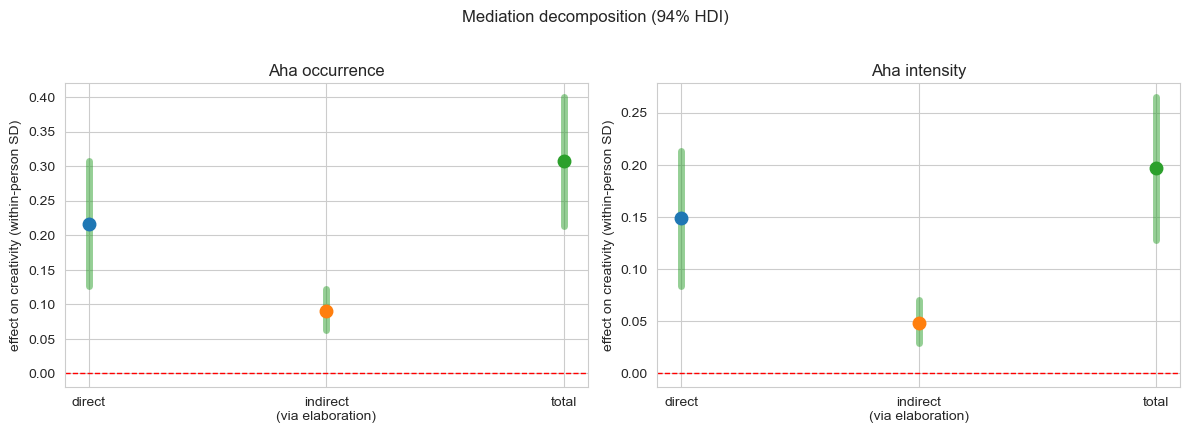

In [7]:
# ---- figure: mediation effects ----
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharex=True)
order = [0, 1, 2]
for ax, title, idx in [(axes[0], "Aha occurrence", order),
                       (axes[1], "Aha intensity", [3, 4, 5])]:
    for k, i in enumerate(idx):
        v = effects[list(effects)[i]]
        lo, hi = np.quantile(v, [0.03, 0.97])
        ax.plot([k, k], [lo, hi], lw=5, alpha=0.5,
                color="tab:green" if lo > 0 else "tab:grey")
        ax.plot(k, v.mean(), "o", ms=9)
    ax.axhline(0, color="red", ls="--", lw=1)
    ax.set_xticks(range(3), ["direct", "indirect\n(via elaboration)", "total"])
    ax.set_title(title)
    ax.set_ylabel("effect on creativity (within-person SD)")
fig.suptitle("Mediation decomposition (94% HDI)", y=1.02)
fig.tight_layout()
save_fig(fig, "mediation.png")
plt.show()

Sampling: [crea]


Output()

saved: figures/ppc_gap.png


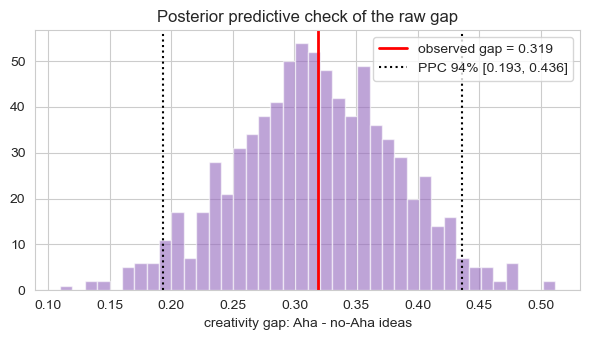

In [8]:
# ---- PPC: does the model reproduce the Aha-creativity gap? ----
with m_main:
    ppc = pm.sample_posterior_predictive(idata_main, var_names=["crea"], random_seed=RANDOM_SEED,
                                         extend_inferencedata=True)
ppc_crea = (ppc.posterior_predictive["crea"].stack(s=("chain", "draw"))
            .transpose("s", "crea_dim_0").values)

obs_gap = crea[aha_bin == 1].mean() - crea[aha_bin == 0].mean()
gap_draws = np.array([d[aha_bin == 1].mean() - d[aha_bin == 0].mean() for d in ppc_crea[::10]])
lo, hi = np.quantile(gap_draws, [0.03, 0.97])

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(gap_draws, bins=40, color="tab:purple", alpha=0.6)
ax.axvline(obs_gap, color="red", lw=2, label=f"observed gap = {obs_gap:.3f}")
ax.axvline(lo, color="k", ls=":"); ax.axvline(hi, color="k", ls=":",
           label=f"PPC 94% [{lo:.3f}, {hi:.3f}]")
ax.set_xlabel("creativity gap: Aha - no-Aha ideas")
ax.set_title("Posterior predictive check of the raw gap")
ax.legend()
fig.tight_layout()
save_fig(fig, "ppc_gap.png")
plt.show()

## 4. Sensitivity: does the conclusion depend on the covariate?

Refit without the sequence covariate — if the Aha effects barely move, the serial-order
adjustment is not doing the scientific work.

In [9]:
with pm.Model() as m_no_trial:
    sigma_uE = pm.Exponential("sigma_u_elab", SIGMA_RATE)
    z_uE = pm.Normal("z_u_elab", 0, 1, shape=len(pids))
    sigma_uC = pm.Exponential("sigma_u_crea", SIGMA_RATE)
    z_uC = pm.Normal("z_u_crea", 0, 1, shape=len(pids))
    bE0 = pm.Normal("b_elab_int", 0, BETA_SD)
    bEa = pm.Normal("b_elab_aha", 0, BETA_SD)
    bEr = pm.Normal("b_elab_aha_rating", 0, BETA_SD)
    muE = bE0 + bEa * aha_bin + bEr * aha_rating + sigma_uE * z_uE[pidx]
    pm.Normal("elab", mu=muE, sigma=pm.Exponential("sigma_elab", SIGMA_RATE), observed=elab)
    bC0 = pm.Normal("b_crea_int", 0, BETA_SD)
    bCa = pm.Normal("b_crea_aha", 0, BETA_SD)
    bCr = pm.Normal("b_crea_aha_rating", 0, BETA_SD)
    bCe = pm.Normal("b_crea_elab", 0, BETA_SD)
    muC = bC0 + bCa * aha_bin + bCr * aha_rating + bCe * elab + sigma_uC * z_uC[pidx]
    pm.Normal("crea", mu=muC, sigma=pm.Exponential("sigma_crea", SIGMA_RATE), observed=crea)
    idata_nt = pm.sample(draws=1500, tune=1000, chains=4, target_accept=0.9,
                         random_seed=RANDOM_SEED)

pnt = idata_nt.posterior.stack(s=("chain", "draw"))
print("direct Aha -> creativity, no-trial model:",
      round(float(pnt["b_crea_aha"].mean()), 3), "[94% HDI",
      np.round(np.quantile(pnt["b_crea_aha"].values, [0.03, 0.97]), 3), "]")
print("vs main model:",
      round(float(p["b_crea_aha"].mean()), 3))

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [sigma_u_elab, z_u_elab, sigma_u_crea, z_u_crea, b_elab_int, b_elab_aha, b_elab_aha_rating, sigma_elab, b_crea_int, b_crea_aha, b_crea_aha_rating, b_crea_elab, sigma_crea]


Output()

Sampling 4 chains for 1_000 tune and 1_500 draw iterations (4_000 + 6_000 draws total) took 3 seconds.


direct Aha -> creativity, no-trial model: 0.225 [94% HDI [0.136 0.314] ]
vs main model: 0.216


## 5. What the analysis says

| Question | Finding |
|---|---|
| Serial order confound real? | Yes — all three time effects present at 0.95 |
| Aha ideas more creative (raw)? | Yes (+0.32 SD in the small model) |
| ...after controlling sequence & elaboration? | **Yes — direct ≈ +0.22 SD, P(>0) = 1.00** |
| Mediated by elaboration? | Partly — indirect ≈ +0.09 SD (~30 % of the total) |
| Intensity matters beyond occurrence? | Yes — direct ≈ +0.15 SD |
| Conclusion sensitive to the covariate? | No — without-trial estimates move by < 0.02 SD |

**The scientific story.** The Aha! experience is not an epiphenomenon of session dynamics:
even within a person, controlling for how late the idea came and how elaborate it is,
Aha-accompanied ideas are about a fifth of a standard deviation more creative, and about a
third of the total effect flows through elaboration — Aha ideas are *richer* ideas, and
richer ideas are more creative.

### Exercises
1. Add the exploratory "sequence as mediator" model from the project history and show its
   indirect effect is meaningless — where exactly does the causal reading break?
2. Fit the model with `elaboration` as the outcome and creativity as the mediator; why is
   that ordering wrong?
3. Replace the participant random intercept with intercept + Aha-slope: do "Aha-boosted"
   participants exist?
4. Use `az.compare` to weigh the main model against the no-trial variant — which is
   preferred, and why is predictive comparison not the right tool for covariate adjustment?
5. Simulate: with these effect sizes, how many ideas per participant would a replication need
   to detect the indirect path at the 0.95 rule?

## References

* Webb, M. E., Little, D. R., & Cropper, S. J. (2018). Insight is not in the problem: insight
  and strategic problem solving. *Quarterly Journal of Experimental Psychology, 71*(6).
* Runco, M. A., & Jaeger, G. J. (2012). The standard definition of creativity.
  *Creativity Research Journal, 24*(1), 92–96.
* Baron, R. M., & Kenny, D. A. (1986). The moderator–mediator variable distinction.
  *J. Pers. Soc. Psychol., 51*(6), 1173–1182.
* Imai, K., Keele, L., & Tingley, D. (2010). A general approach to causal mediation analysis.
  *Psychological Methods, 15*(4), 309–334.
* McElreath, R. (2020). *Statistical Rethinking* (2nd ed.). CRC Press.

*Data and the final `v1` pipeline: Moroshkina-lab Aha/Creativity project; this notebook
re-implements its main model and reproduces its reported effect tables.*